In [1]:
import pandas as pd

credit = pd.read_csv('data/credit_final.csv')
credit = credit.rename(columns={'age_groups_60+': 'age_groups_60_plus',
                                'age_groups_=<30': 'age_groups_less_equal_30'})

# Podział zbioru

In [2]:
from sklearn.model_selection import train_test_split

X = credit.drop(columns=['risk'])
y = credit['risk']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
y.value_counts(normalize=True)

risk
1    0.7
0    0.3
Name: proportion, dtype: float64

# Drzewo decyzyjne

In [4]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

clf_tree = DecisionTreeClassifier(random_state=42, max_depth=3)
clf_tree.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

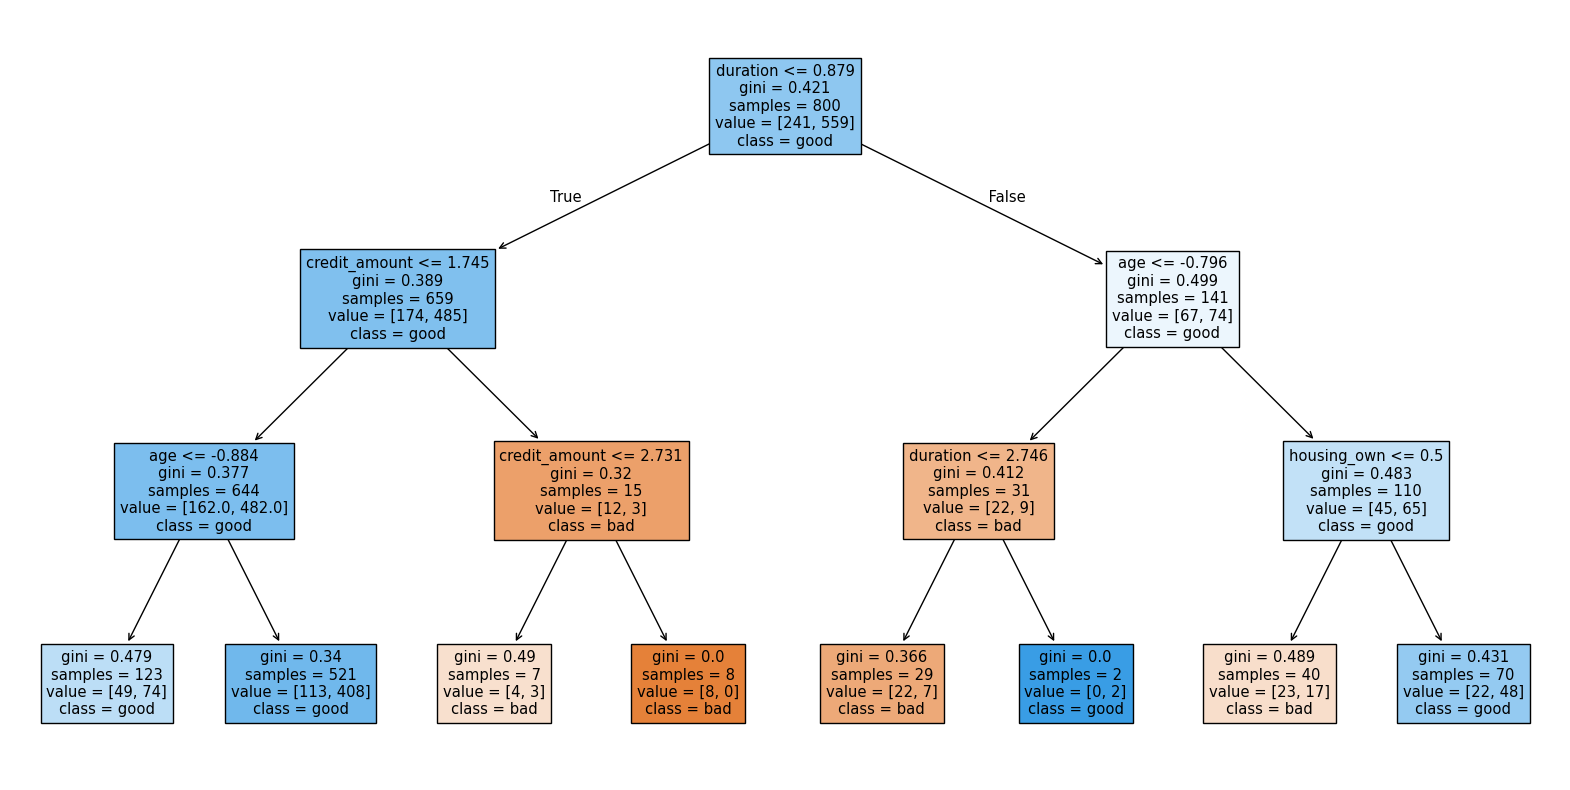

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(clf_tree, filled=True, feature_names=X.columns, class_names=['bad', 'good'])
plt.show()

## Ocena jakości modelu

In [6]:
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                             precision_score, recall_score, f1_score, balanced_accuracy_score)

y_pred_train_tree = clf_tree.predict(X_train)
confusion_matrix(y_train, y_pred_train_tree)

array([[ 57, 184],
       [ 27, 532]])

In [7]:
print(classification_report(y_train, y_pred_train_tree))

              precision    recall  f1-score   support

           0       0.68      0.24      0.35       241
           1       0.74      0.95      0.83       559

    accuracy                           0.74       800
   macro avg       0.71      0.59      0.59       800
weighted avg       0.72      0.74      0.69       800



In [8]:
def evaluate_model(y_true, y_pred):

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    accuracy = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    specificity = tn / (tn + fp)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print(f"Specificity: {specificity:.4f}")
    

In [9]:
evaluate_model(y_train, y_pred_train_tree)

Confusion Matrix:
[[ 57 184]
 [ 27 532]]
Accuracy: 0.7362
Balanced Accuracy: 0.5941
Precision: 0.7430
Recall: 0.9517
F1 Score: 0.8345
Specificity: 0.2365


In [10]:
y_pred_test_tree = clf_tree.predict(X_test)
evaluate_model(y_test, y_pred_test_tree)

Confusion Matrix:
[[ 11  48]
 [  8 133]]
Accuracy: 0.7200
Balanced Accuracy: 0.5649
Precision: 0.7348
Recall: 0.9433
F1 Score: 0.8261
Specificity: 0.1864


Accuracy = 0,72 = 72% dokładności modelu

Balanced accuracy = 0,56 = 56% trafności modelu z uwzględnieniem nierównowagi klas

Precision (precyzja) = 0,73 = 73% klientów zaklasyfikowanych jako dobrzy klienci to rzeczywiście dobrzy klienci

Recall (czułość) = 0,94 = udaje się zaklasyfikować 94% dobrych klientów, a tylko 6% klasyfikuje jako złych

Specificity (swoistość) = 0,18 = tylko 18% złych klientów zostało poprawnie rozpoznanych, a 82% złych klientów jest klasyfikowanych jako dobrzy klienci

F1-score = 0,82 = 82% skutczności modelu dla klasy dobrzy klienci

# Krzywa ROC

AUC: 0.5448


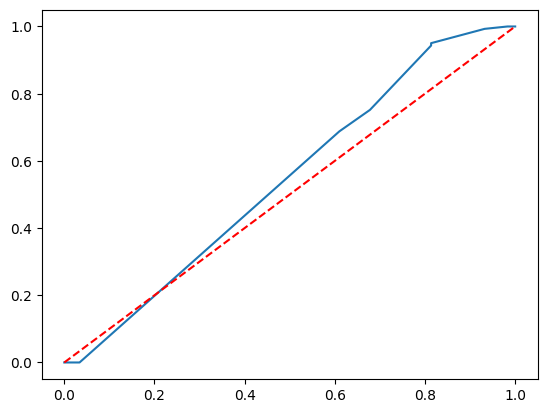

In [11]:
from sklearn.metrics import roc_auc_score, roc_curve

y_pred_proba_test_tree = clf_tree.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test_tree)
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle='--', color='red')
print(f"AUC: {roc_auc_score(y_test, y_pred_proba_test_tree):.4f}")

# Maszyna wektorów nośnych (SVM)

In [12]:
from sklearn.svm import SVC

# clf_svm = SVC(random_state=42, probability=True, kernel='linear')
# clf_svm = SVC(random_state=42, probability=True, kernel='poly')
clf_svm = SVC(random_state=42, probability=True, kernel='rbf')
# clf_svm = SVC(random_state=42, probability=True, kernel='sigmoid')
clf_svm.fit(X_train, y_train)

y_pred_train_svm = clf_svm.predict(X_train)
y_pred_test_svm = clf_svm.predict(X_test)

In [13]:
evaluate_model(y_train, y_pred_train_svm)

Confusion Matrix:
[[ 70 171]
 [ 10 549]]
Accuracy: 0.7738
Balanced Accuracy: 0.6363
Precision: 0.7625
Recall: 0.9821
F1 Score: 0.8585
Specificity: 0.2905


In [14]:
evaluate_model(y_test, y_pred_test_svm)

Confusion Matrix:
[[  7  52]
 [  9 132]]
Accuracy: 0.6950
Balanced Accuracy: 0.5274
Precision: 0.7174
Recall: 0.9362
F1 Score: 0.8123
Specificity: 0.1186


AUC: 0.6751


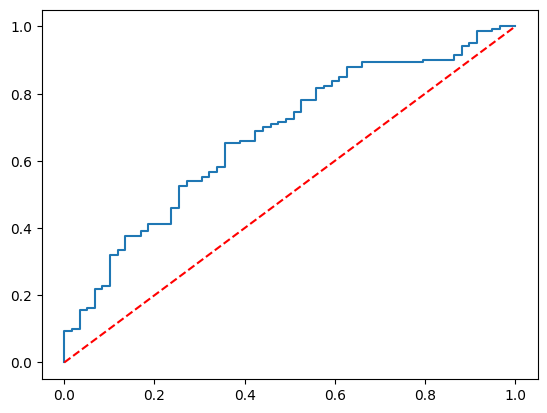

In [15]:
def roc_plot(y_true, X, model):
    y_pred_proba = model.predict_proba(X)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], linestyle='--', color='red')
    print(f"AUC: {roc_auc_score(y_true, y_pred_proba):.4f}")

roc_plot(y_test, X_test, clf_svm)

# Las losowy

In [16]:
from sklearn.ensemble import RandomForestClassifier

clf_rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=7)
clf_rf.fit(X_train, y_train)

y_pred_train_rf = clf_rf.predict(X_train)
y_pred_test_rf = clf_rf.predict(X_test)

In [17]:
evaluate_model(y_train, y_pred_train_rf)

Confusion Matrix:
[[101 140]
 [  0 559]]
Accuracy: 0.8250
Balanced Accuracy: 0.7095
Precision: 0.7997
Recall: 1.0000
F1 Score: 0.8887
Specificity: 0.4191


In [18]:
evaluate_model(y_test, y_pred_test_rf)

Confusion Matrix:
[[ 10  49]
 [  7 134]]
Accuracy: 0.7200
Balanced Accuracy: 0.5599
Precision: 0.7322
Recall: 0.9504
F1 Score: 0.8272
Specificity: 0.1695


AUC: 0.6556


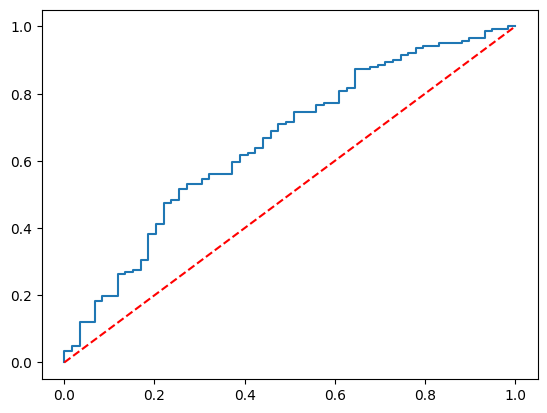

In [19]:
roc_plot(y_test, X_test, clf_rf)

# Boosting gradientowy

In [20]:
from sklearn.ensemble import GradientBoostingClassifier

clf_gb = GradientBoostingClassifier(random_state=42, n_estimators=40, max_depth=7)
clf_gb.fit(X_train, y_train)

y_pred_train_gb = clf_gb.predict(X_train)
y_pred_test_gb = clf_gb.predict(X_test)

In [21]:
evaluate_model(y_train, y_pred_train_gb)

Confusion Matrix:
[[228  13]
 [  0 559]]
Accuracy: 0.9838
Balanced Accuracy: 0.9730
Precision: 0.9773
Recall: 1.0000
F1 Score: 0.9885
Specificity: 0.9461


In [22]:
evaluate_model(y_test, y_pred_test_gb)

Confusion Matrix:
[[ 15  44]
 [ 15 126]]
Accuracy: 0.7050
Balanced Accuracy: 0.5739
Precision: 0.7412
Recall: 0.8936
F1 Score: 0.8103
Specificity: 0.2542


AUC: 0.6833


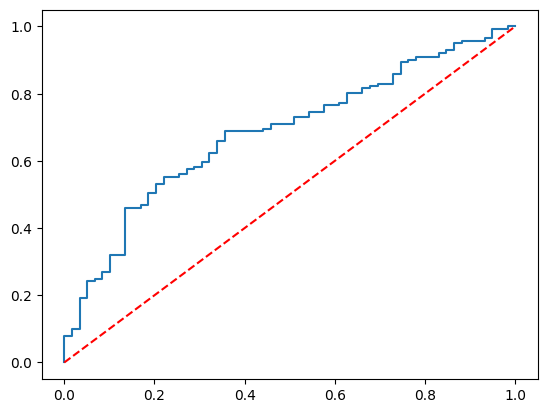

In [23]:
roc_plot(y_test, X_test, clf_gb)

In [24]:
! pip install xgboost


[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
from xgboost import XGBClassifier

clf_xgb = XGBClassifier(random_state=42, n_estimators=40, max_depth=7)
clf_xgb.fit(X_train, y_train)

y_pred_train_xgb = clf_xgb.predict(X_train)
y_pred_test_xgb = clf_xgb.predict(X_test)

In [26]:
evaluate_model(y_train, y_pred_train_xgb)

Confusion Matrix:
[[233   8]
 [  0 559]]
Accuracy: 0.9900
Balanced Accuracy: 0.9834
Precision: 0.9859
Recall: 1.0000
F1 Score: 0.9929
Specificity: 0.9668


In [27]:
evaluate_model(y_test, y_pred_test_xgb)

Confusion Matrix:
[[ 16  43]
 [ 21 120]]
Accuracy: 0.6800
Balanced Accuracy: 0.5611
Precision: 0.7362
Recall: 0.8511
F1 Score: 0.7895
Specificity: 0.2712


AUC: 0.6676


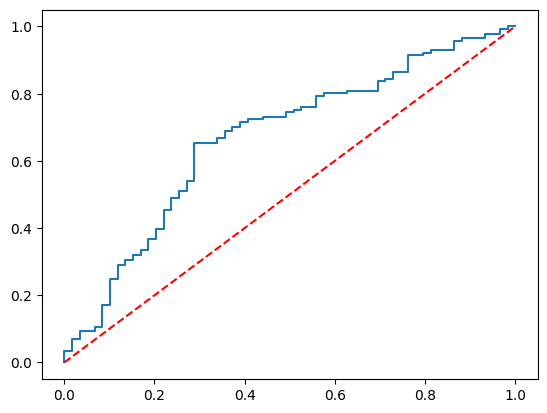

In [28]:
roc_plot(y_test, X_test, clf_xgb)

# Walidacja krzyżowa

In [29]:
from sklearn.model_selection import cross_val_score

scores_cv = cross_val_score(clf_xgb, X_train, y_train, cv=5, scoring='roc_auc')
scores_cv

array([0.64938408, 0.61160714, 0.67150298, 0.6577381 , 0.68024554])

In [30]:
print(scores_cv.mean())

0.6540955655911013


# Tuning hiperparametrów

## Pełne przeszukiwanie siatki

In [31]:
from sklearn.model_selection import GridSearchCV

param_distributions = {
    'n_estimators': [100, 250, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7]
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_grid=param_distributions,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=16
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 192 candidates, totalling 960 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_weight': [1, 3, ...], 'n_estimators': [100, 250, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",16
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold a

In [32]:
grid_search.best_score_

np.float64(0.6728080041138076)

In [33]:
grid_search.best_params_

{'learning_rate': 0.1,
 'max_depth': 3,
 'min_child_weight': 3,
 'n_estimators': 100}

In [34]:
clf_xgb_best = grid_search.best_estimator_
y_pred_test_xgb_best = clf_xgb_best.predict(X_test)
evaluate_model(y_test, y_pred_test_xgb_best)

Confusion Matrix:
[[ 17  42]
 [ 12 129]]
Accuracy: 0.7300
Balanced Accuracy: 0.6015
Precision: 0.7544
Recall: 0.9149
F1 Score: 0.8269
Specificity: 0.2881


AUC: 0.6813


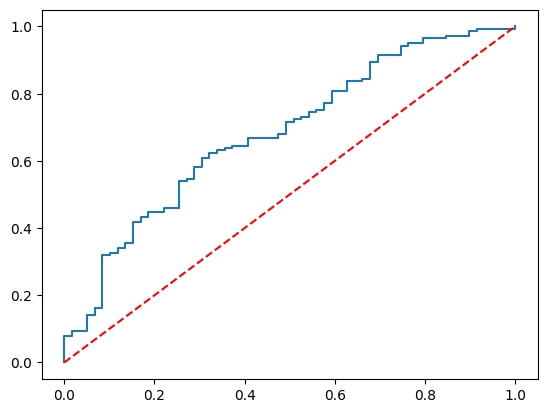

In [35]:
roc_plot(y_test, X_test, clf_xgb_best)

## Losowe przeszukiwanie siatki

In [30]:
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_child_weight': [1, 3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5, 1],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [1, 5, 10]
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42),
    param_distributions=param_distributions,
    n_iter=100,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=16
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 100 candidates, totalling 500 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...ree=None, ...)"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'colsample_bytree': [0.6, 0.8, ...], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",100
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",16
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.

In [37]:
random_search.best_score_

np.float64(0.694863916850524)

In [38]:
random_search.best_params_

{'subsample': 0.8,
 'reg_lambda': 10,
 'reg_alpha': 1,
 'n_estimators': 1000,
 'min_child_weight': 5,
 'max_depth': 7,
 'learning_rate': 0.01,
 'gamma': 1,
 'colsample_bytree': 0.6}

In [31]:
clf_xgb_best_random = random_search.best_estimator_
y_pred_test_xgb_best_random = clf_xgb_best_random.predict(X_test)
evaluate_model(y_test, y_pred_test_xgb_best_random)

Confusion Matrix:
[[ 16  43]
 [ 13 128]]
Accuracy: 0.7200
Balanced Accuracy: 0.5895
Precision: 0.7485
Recall: 0.9078
F1 Score: 0.8205
Specificity: 0.2712


AUC: 0.6720


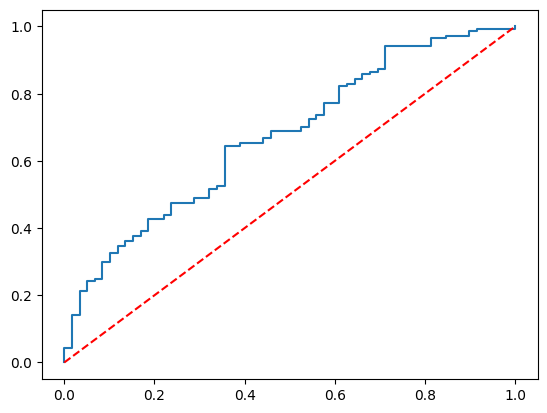

In [40]:
roc_plot(y_test, X_test, clf_xgb_best_random)

## Zadanie - las losowy

In [41]:
param_distributions_rf = {
    'n_estimators': [100, 300, 500, 1000],
    'max_depth': [None, 10, 20, 30, 40, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True, False],
    'criterion': ['gini', 'entropy']
}

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_distributions_rf,
    n_iter=200,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=16
)

random_search_rf.fit(X_train, y_train)

Fitting 5 folds for each of 200 candidates, totalling 1000 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'bootstrap': [True, False], 'criterion': ['gini', 'entropy'], 'max_depth': [None, 10, ...], 'max_features': ['sqrt', 'log2'], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",200
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",16
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here

In [42]:
random_search_rf.best_score_

np.float64(0.6963321899705829)

In [43]:
random_search.best_params_

{'subsample': 0.8,
 'reg_lambda': 10,
 'reg_alpha': 1,
 'n_estimators': 1000,
 'min_child_weight': 5,
 'max_depth': 7,
 'learning_rate': 0.01,
 'gamma': 1,
 'colsample_bytree': 0.6}

In [44]:
clf_rf_best_random = random_search_rf.best_estimator_
y_pred_test_rf_best_random = clf_rf_best_random.predict(X_test)
evaluate_model(y_test, y_pred_test_rf_best_random)

Confusion Matrix:
[[ 11  48]
 [  7 134]]
Accuracy: 0.7250
Balanced Accuracy: 0.5684
Precision: 0.7363
Recall: 0.9504
F1 Score: 0.8297
Specificity: 0.1864


AUC: 0.6685


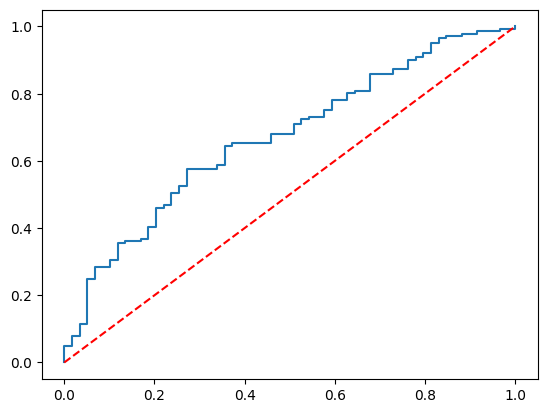

In [45]:
roc_plot(y_test, X_test, clf_rf_best_random)

# Ważność cech

In [46]:
clf_xgb_best_random.feature_importances_

array([0.04136543, 0.03821445, 0.0500848 , 0.03795727, 0.03746513,
       0.02859509, 0.02671531, 0.        , 0.02379736, 0.02855218,
       0.03177908, 0.04095659, 0.05514003, 0.03089263, 0.02833206,
       0.02547259, 0.01726292, 0.02167553, 0.0276237 , 0.03394023,
       0.01595402, 0.02911847, 0.03136946, 0.        , 0.0222226 ,
       0.02544245, 0.04147548, 0.        , 0.        , 0.03368377,
       0.03109217, 0.03442438, 0.03475628, 0.01830756, 0.05633098],
      dtype=float32)

In [47]:
fi_df = pd.DataFrame({
    'feature': X.columns,
    'importance': clf_xgb_best_random.feature_importances_
}).sort_values(by='importance', ascending=False)
fi_df

,feature,importance
34,age_groups_less_equal_30,0.056331
12,housing_own,0.055140
2,duration,0.050085
26,purpose_radio_tv,0.041475
0,age,0.041365
11,housing_free,0.040957
1,credit_amount,0.038214
3,installment_rate,0.037957
4,installment_rate_by_checking_account,0.037465
32,age_groups_41_60,0.034756


In [48]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(clf_xgb_best_random, X_test, y_test, n_repeats=30, random_state=42)

In [49]:
perm_importance.importances_mean

array([ 0.01866667,  0.027     ,  0.037     ,  0.04816667,  0.01066667,
        0.01566667,  0.004     ,  0.        ,  0.0015    ,  0.00183333,
       -0.00033333,  0.009     ,  0.0195    ,  0.005     ,  0.01083333,
        0.0005    , -0.00033333,  0.00066667, -0.00366667,  0.00833333,
        0.        ,  0.0005    ,  0.00283333,  0.        ,  0.0005    ,
        0.00433333,  0.002     ,  0.        ,  0.        ,  0.0015    ,
        0.00066667,  0.011     ,  0.        ,  0.        ,  0.00783333])

In [50]:
fi_df_perm = pd.DataFrame({
    'feature': X.columns,
    'importance': perm_importance.importances_mean
}).sort_values(by='importance', ascending=False)
fi_df_perm

,feature,importance
3,installment_rate,0.048167
2,duration,0.037000
1,credit_amount,0.027000
12,housing_own,0.019500
0,age,0.018667
5,sex_female,0.015667
31,age_groups_31_40,0.011000
14,saving_accounts_little,0.010833
4,installment_rate_by_checking_account,0.010667
11,housing_free,0.009000


# Wartości SHAP

In [ ]:
! pip install shap

In [32]:
import shap

explainer = shap.Explainer(clf_xgb_best_random, X_train)
shap_values = explainer(X_test)

d:\CDV\mad_gr1\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Background dataset has 800 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=800 when initializing the masker.


In [33]:
shap_values

.values =
array([[-0.4780576 ,  0.27378511,  0.00321473, ...,  0.00384282,
         0.        ,  0.        ],
       [ 0.24057808, -0.24165178, -0.03872478, ...,  0.00824862,
         0.        ,  0.        ],
       [-0.04157381,  0.18403283,  0.02420497, ...,  0.00363432,
         0.        ,  0.        ],
       ...,
       [-0.40258676, -0.45323601,  0.04185827, ...,  0.00702908,
         0.        ,  0.        ],
       [-0.58045124,  0.28451061,  0.00982673, ...,  0.00245396,
         0.        ,  0.        ],
       [ 0.2756593 , -0.66825842, -0.32017016, ...,  0.00861583,
         0.        ,  0.        ]], shape=(200, 35))

.base_values =
array([0.88785218, 0.88785218, 0.88785218, 0.88785218, 0.88785218,
       0.88785218, 0.88785218, 0.88785218, 0.88785218, 0.88785218,
       0.88785218, 0.88785218, 0.88785218, 0.88785218, 0.88785218,
       0.88785218, 0.88785218, 0.88785218, 0.88785218, 0.88785218,
       0.88785218, 0.88785218, 0.88785218, 0.88785218, 0.88785218,
       0.

In [35]:
client_id = 2

y_pred_test_xgb_best_random[client_id]

np.int64(1)

In [36]:
shap_results = pd.DataFrame({
    'feature': X.columns,
    'shap_value': shap_values[client_id].values
}).sort_values(by='shap_value', key=abs, ascending=False)
shap_results

,feature,shap_value
14,saving_accounts_little,0.265634
12,housing_own,0.205952
3,installment_rate,-0.196196
1,credit_amount,0.184033
26,purpose_radio_tv,-0.105240
4,installment_rate_by_checking_account,0.100651
5,sex_female,0.088118
15,saving_accounts_moderate,-0.061527
0,age,-0.041574
22,purpose_car,-0.034651
